In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, classification_report, roc_curve, auc)

##EDA


In [2]:
# Load dataset
breast_cancer = load_breast_cancer()
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target)

print(f"✓ Dataset berhasil dimuat!")
print(f"  - Jumlah sampel: {X.shape[0]}")
print(f"  - Jumlah fitur: {X.shape[1]}")
print(f"  - Distribusi Benign: {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"  - Distribusi Malignant: {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)")

✓ Dataset berhasil dimuat!
  - Jumlah sampel: 569
  - Jumlah fitur: 30
  - Distribusi Benign: 212 (37.3%)
  - Distribusi Malignant: 357 (62.7%)


In [37]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [3]:
# EDA: Statistik Deskriptif
print("\nSTATISTIK DESKRIPTIF")
print(X.describe())


STATISTIK DESKRIPTIF
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000            

In [4]:
# EDA: Cek Missing Values
print(f"\n✓ Missing values: {X.isnull().sum().sum()} (tidak ada)")


✓ Missing values: 0 (tidak ada)


##Pre-Processing

In [38]:
corr_with_target = X.copy()
corr_with_target['target'] = y

corr_target = corr_with_target.corr()['target'].abs().sort_values(ascending=False)

# ambil top 15 fitur terbaik
selected_features = corr_target[1:16].index

X = X[selected_features]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['worst concave points', 'worst perimeter', 'mean concave points',
       'worst radius', 'mean perimeter', 'worst area', 'mean radius',
       'mean area', 'mean concavity', 'worst concavity', 'mean compactness',
       'worst compactness', 'radius error', 'perimeter error', 'area error'],
      dtype='object')


In [39]:
# Preprocessing: Feature Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [40]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✓ Data telah di-scale dan di-split")
print(f"  - Training: {X_train.shape[0]} sampel")
print(f"  - Testing: {X_test.shape[0]} sampel")


✓ Data telah di-scale dan di-split
  - Training: 455 sampel
  - Testing: 114 sampel


In [41]:
# Simpan preprocessing data untuk nantinya
preprocessing_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'scaler': scaler,
    'feature_names': X.columns.tolist()
}

##TPOT Auto ML

In [43]:
print("\n" + "=" * 80)
print("FASE 3: TPOT AUTOML (GENETIC PROGRAMMING)")
print("=" * 80)

print("\n📌 TPOT akan mencari pipeline optimal dengan genetic programming")
print("   Configuration: 15 generations, 15 population size")
print("   ⏱️  Estimasi waktu: 15-20 menit\n")

# Install TPOT jika belum ada
import subprocess
import sys

try:
    import tpot
    print("✓ TPOT sudah terinstall")
except ImportError:
    print("Installing TPOT...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tpot", "-q"])
    print("✓ TPOT berhasil diinstall")

from tpot import TPOTClassifier

print("\n⏱️  Memasuki fase TPOT optimization...")

# Konfigurasi TPOT (versi baru compatible)
tpot = TPOTClassifier(
    generations=15,
    population_size=15,
    cv=5,
    n_jobs=1, # Changed from -1 to 1 to address worker timeout issues
    random_state=42,
    max_time_mins=15
)

# Training TPOT
tpot.fit(X_train.values, y_train.values)

print("\n✓ TPOT Optimization selesai!")

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:46711
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:42181/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:39585'



FASE 3: TPOT AUTOML (GENETIC PROGRAMMING)

📌 TPOT akan mencari pipeline optimal dengan genetic programming
   Configuration: 15 generations, 15 population size
   ⏱️  Estimasi waktu: 15-20 menit

✓ TPOT sudah terinstall

⏱️  Memasuki fase TPOT optimization...


INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:36643 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:36643
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:44258
INFO:distributed.scheduler:Receive client connection: Client-015c25eb-34f9-11f1-a2c3-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:44274
Generation: 100%|██████████| 15/15 [06:46<00:00, 27.12s/it]
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1775838357.9532444') (0,)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:39585'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:44258; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:36643 name: 0 (stimulus_id='handle-worker-cleanup-1775838357.9654763')
ERROR:distributed.scheduler:Removing worker


✓ TPOT Optimization selesai!


In [54]:
print("\n" + "="*80)
print("HASIL TPOT AUTOML")
print("="*80)

# Best pipeline yang ditemukan
if hasattr(tpot, "fitted_pipeline_"):
    print("\nBest Pipeline dari TPOT:")
    print(tpot.fitted_pipeline_)
else:
    print("\nBest Pipeline tidak tersedia. TPOT mungkin belum menyelesaikan optimasi atau terjadi kesalahan.")



HASIL TPOT AUTOML

Best Pipeline dari TPOT:
Pipeline(steps=[('normalizer', Normalizer(norm=np.str_('l2'))),
                ('selectfwe', SelectFwe(alpha=0.0427353329613)),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('sgdclassifier',
                 SGDClassifier(alpha=0.0011303304717, class_weight='balanced',
                               eta0=0.1748662674173, fit_intercept=np.True_,
                            

In [55]:
print("\nHyperparameter Optimasi dari Best Model (TPOT):")
if 'final_estimator' in locals():
    print(final_estimator.get_params())
else:
    print("Variabel 'final_estimator' tidak ditemukan. Pastikan cell yang mengekstrak model terbaik TPOT telah dieksekusi.")


Hyperparameter Optimasi dari Best Model (TPOT):
{'categorical_features': 'from_dtype', 'class_weight': None, 'early_stopping': True, 'interaction_cst': None, 'l2_regularization': 0.2033234811368, 'learning_rate': 0.2422405234839, 'loss': 'log_loss', 'max_bins': 255, 'max_depth': None, 'max_features': 0.1161213648432, 'max_iter': 100, 'max_leaf_nodes': 1147, 'min_samples_leaf': 39, 'monotonic_cst': None, 'n_iter_no_change': 19, 'random_state': 42, 'scoring': 'loss', 'tol': 0.0001, 'validation_fraction': None, 'verbose': 0, 'warm_start': False}



CONFUSION MATRIX TPOT AUTOML

✓ Confusion matrix TPOT disimpan: 03_confusion_matrix_tpot.png


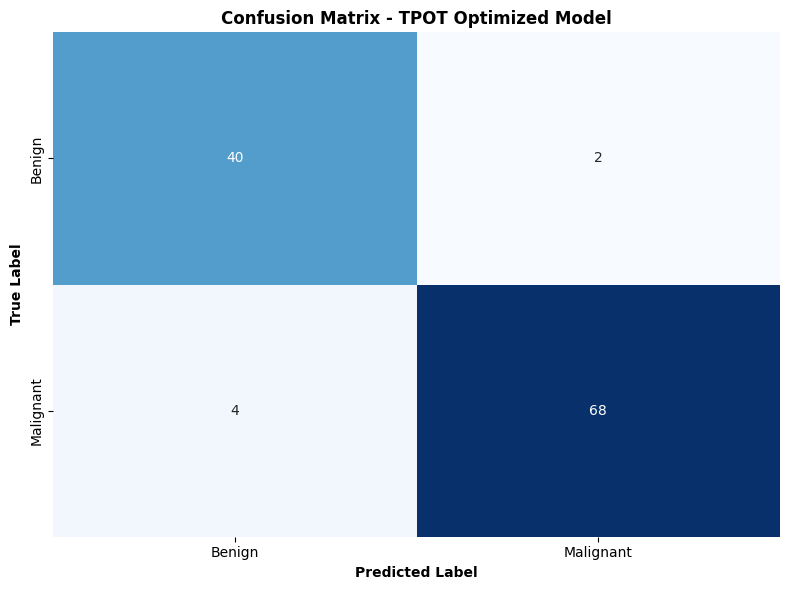

In [56]:
print("\n" + "="*80)
print("CONFUSION MATRIX TPOT AUTOML")
print("="*80)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Memastikan y_pred_tpot sudah tersedia dari eksekusi sebelumnya
if 'y_pred_tpot' not in locals():
    print("Error: y_pred_tpot tidak ditemukan. Pastikan cell TPOT sudah dieksekusi.")
else:
    cm_tpot = confusion_matrix(y_test, y_pred_tpot)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm_tpot, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
               xticklabels=['Benign', 'Malignant'],
               yticklabels=['Benign', 'Malignant'])
    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_title('Confusion Matrix - TPOT Optimized Model', fontweight='bold')
    plt.tight_layout()
    plt.savefig('03_confusion_matrix_tpot.png', dpi=100, bbox_inches='tight')
    print("\n✓ Confusion matrix TPOT disimpan: 03_confusion_matrix_tpot.png")
    plt.show()

##PSO

In [57]:
print("\n" + "=" * 80)
print("FASE 5: HYPERPARAMETER OPTIMIZATION (PSO)")
print("=" * 80)

# Instal pyswarm jika belum ada
import subprocess
import sys

try:
    import pyswarm
    print("✓ pyswarm sudah terinstall")
except ImportError:
    print("Installing pyswarm...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyswarm", "-q"])
    print("✓ pyswarm berhasil diinstall")

from pyswarm import pso
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score



FASE 5: HYPERPARAMETER OPTIMIZATION (PSO)
✓ pyswarm sudah terinstall


### Konfigurasi Ruang Pencarian Hyperparameter untuk `HistGradientBoostingClassifier`

Kita akan fokus pada beberapa hyperparameter kunci:
-   `learning_rate`: Mengontrol seberapa besar langkah yang diambil setiap kali bobot diperbarui.
-   `max_depth`: Kedalaman maksimum dari masing-masing pohon boosting.
-   `n_estimators`: Jumlah pohon boosting yang akan digunakan (meskipun `HistGradientBoostingClassifier` menggunakan `max_iter`, kita bisa memetakannya).
-   `min_samples_leaf`: Jumlah minimum sampel yang dibutuhkan untuk menjadi daun di pohon.
-   `l2_regularization`: Kekuatan regularisasi L2.

`HistGradientBoostingClassifier` tidak memiliki `n_estimators`, melainkan `max_iter`. Kita akan memetakan `n_estimators` ke `max_iter`.

In [58]:
# Batas bawah (lb) dan batas atas (ub)
lb = [0.01, 50, 3, 20, 0.0]
ub = [0.3, 500, 15, 100, 1.0]

print("✓ Ruang pencarian hyperparameter telah didefinisikan.")
print(f"  - Lower Bounds: {lb}")
print(f"  - Upper Bounds: {ub}")


✓ Ruang pencarian hyperparameter telah didefinisikan.
  - Lower Bounds: [0.01, 50, 3, 20, 0.0]
  - Upper Bounds: [0.3, 500, 15, 100, 1.0]


### Fungsi Objektif untuk PSO

Fungsi objektif akan menerima set hyperparameter dari PSO, melatih `HistGradientBoostingClassifier` menggunakan cross-validation pada data training, dan mengembalikan `negative accuracy` rata-rata. PSO akan mencoba meminimalkan nilai ini, yang secara efektif memaksimalkan akurasi.

In [59]:
def objective_function(hyperparameters, X_train, y_train):
    # Extract hyperparameters
    learning_rate = hyperparameters[0]
    max_iter = int(hyperparameters[1])
    max_depth = int(hyperparameters[2])
    min_samples_leaf = int(hyperparameters[3])
    l2_regularization = hyperparameters[4]

    # Inisialisasi model dengan hyperparameter yang diberikan
    model = HistGradientBoostingClassifier(
        learning_rate=learning_rate,
        max_iter=max_iter,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        l2_regularization=l2_regularization,
        random_state=42,
        early_stopping=True, # Dari best model TPOT
        n_iter_no_change=19, # Dari best model TPOT
        tol=0.0001 # Dari best model TPOT
    )


    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

    # PSO mencari nilai minimum, jadi kita kembalikan negatif dari akurasi rata-rata
    return -np.mean(scores)

print("✓ Fungsi objektif telah didefinisikan.")


✓ Fungsi objektif telah didefinisikan.


### Menjalankan PSO untuk Optimasi Hyperparameter

Kita akan menjalankan PSO dengan konfigurasi tertentu. Proses ini bisa memakan waktu tergantung pada `iters` dan ukuran populasi.

In [60]:
print("\n⏱️  Memulai optimasi hyperparameter menggunakan PSO...")

# Jalankan PSO
xopt, fopt = pso(
    objective_function,
    lb, # Lower bounds
    ub, # Upper bounds
    args=(X_train, y_train),
    swarmsize=10, # Jumlah partikel dalam swarm
    maxiter=20,   # Jumlah iterasi maksimum
    debug=False
)

print("\n✓ Optimasi PSO selesai!")
print("\n========================================")
print("HASIL OPTIMASI PSO")
print("========================================")
print(f"Best negative accuracy (fopt): {fopt:.4f}")
print(f"Best Accuracy: {-fopt:.4f}")
print(f"Best Hyperparameters (xopt): {xopt}")

# Ekstrak hyperparameter terbaik
best_learning_rate_pso = xopt[0]
best_max_iter_pso = int(xopt[1])
best_max_depth_pso = int(xopt[2])
best_min_samples_leaf_pso = int(xopt[3])
best_l2_regularization_pso = xopt[4]

print("\nBest Hyperparameters:")
print(f"  - learning_rate: {best_learning_rate_pso:.4f}")
print(f"  - max_iter: {best_max_iter_pso}")
print(f"  - max_depth: {best_max_depth_pso}")
print(f"  - min_samples_leaf: {best_min_samples_leaf_pso}")
print(f"  - l2_regularization: {best_l2_regularization_pso:.4f}")



⏱️  Memulai optimasi hyperparameter menggunakan PSO...
Stopping search: maximum iterations reached --> 20

✓ Optimasi PSO selesai!

HASIL OPTIMASI PSO
Best negative accuracy (fopt): -0.9495
Best Accuracy: 0.9495
Best Hyperparameters (xopt): [8.22555393e-02 6.95894107e+01 1.41842431e+01 9.12919457e+01
 1.57748178e-01]

Best Hyperparameters:
  - learning_rate: 0.0823
  - max_iter: 69
  - max_depth: 14
  - min_samples_leaf: 91
  - l2_regularization: 0.1577
